# Chapter 2. Smoothing filters

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import libraries

To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset

In [ ]:
# load the Excel file as a DataFrame
eog_data = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/signal_processing/EOG.xlsx")
display(eog_data.head())

,data_1ch_test,data_2ch_test,data_3ch_test,data_4ch_test,data_5ch_test,data_6ch_test,data_7ch_test,data_8ch_test
0,29417.40,31430.40,15609.38,37966.67,26312.20,33941.21,28682.47,7577.51
1,29408.81,31432.54,15602.68,37987.06,26321.59,33933.97,28674.43,7594.14
2,29403.45,31421.01,15597.85,37993.22,26277.07,33919.49,28669.06,7589.04
3,29404.25,31417.52,15600.27,37980.89,26247.56,33921.36,28673.62,7578.85
4,29408.01,31426.91,15606.70,37966.94,26269.82,33933.43,28673.35,7578.05


Before applying filtering or advanced analysis techniques to EOG signals, it is essential to first visualize the raw data. Plotting the unprocessed EOG signal provides crucial insight into the quality and characteristics of the recording. Raw EOG data often contains noise, motion artifacts, baseline drift, and disturbances from external electrical sources. By examining the unprocessed waveform, we can quickly detect issues such as poor electrode placement, loose connections, unexpected spikes, or saturation of the amplifier.

Understanding the shape, amplitude, and timing of the raw EOG helps us decide what type of processing is required and ensures that we do not unintentionally distort meaningful physiological information. For example, identifying the frequency content, noise sources, or periods of muscle activation becomes much easier when the signal is first viewed in its natural form. Plotting raw data is therefore a fundamental step that guides filter selection, segmentation, normalization, and feature extraction.

In short, visualizing raw EOG data ensures the quality of the recording, prevents incorrect interpretation, and provides a reliable foundation for all later stages of EOG signal processing.

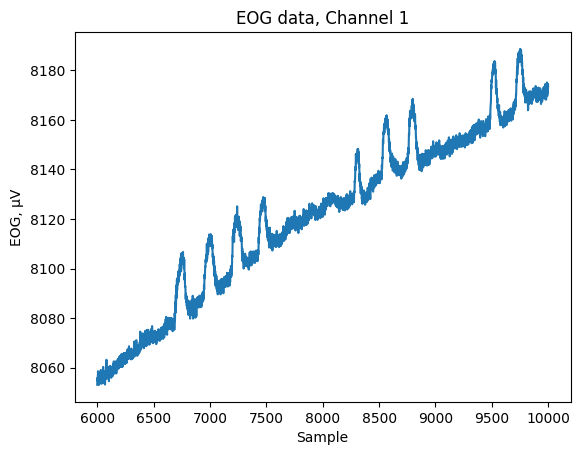

In [ ]:
# select the data from the first channel
channel = 0
channel_data = eog_data.iloc[:, channel]
channel_data = round(1000000*4.5*(channel_data/16777215),2)  # Convert data from ADC to µV
channel_data = channel_data[6000:10000]
# plot the EOG data
plt.plot(channel_data)
plt.title("EOG data, Channel " + str(channel+1))
plt.ylabel('EOG, µV')
plt.xlabel('Sample')
plt.show()

The raw EOG-contaminated signal demonstrates several important characteristics that highlight why initial visualization is essential before applying signal-processing techniques. The recording shows a clear baseline drift, indicating slow changes in electrode or skin impedance, as well as prominent high-frequency bursts and sharp transients produced by intentional muscle activations performed in a 4-3-2-1 sequence. These bursts dominate the waveform and create strong amplitude fluctuations typical of EOG interference. The combination of drift, noise, and high-intensity muscle activity makes this dataset an ideal example of a “dirty” raw signal, illustrating the need for preprocessing steps such as detrending, filtering, and segmentation. This graph effectively demonstrates the challenges of working with real physiological data and provides a valuable foundation for teaching EOG signal-processing methods.

**Signal Processing**  
In physiological signal analysis, raw recordings such as EEG or EOG often contain unwanted components that can obscure the true activity of interest. Before we extract features or interpret muscle or brain activity, it is essential to perform basic preprocessing, a stage of signal processing focused on cleaning and preparing the data

**Zero-meaning remove**

In physiological signal analysis, raw recordings such as EEG or EOG often contain unwanted components that can obscure the true activity of interest. Before we extract features or interpret muscle or brain activity, it is essential to perform basic preprocessing, a stage of signal processing focused on cleaning and preparing the data. The script below demonstrates two fundamental preprocessing techniques: zero-meaning and detrending. Zero-meaning removes the constant offset (DC component) from the signal, centering it around zero so that amplitude changes reflect real physiological fluctuations rather than sensor bias. Detrending removes slow baseline drift caused by movement, electrode impedance variation, or environmental factors. Together, these steps eliminate low-frequency artifacts and reveal the meaningful dynamic content of the signal. This type of preprocessing is crucial because clean, stable data provides the foundation for accurate filtering, segmentation, and feature extraction later in the EOG/EEG signal-processing pipeline.

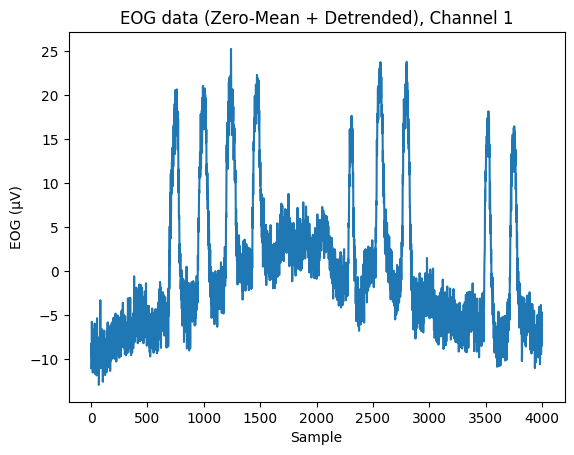

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import detrend

# Select channel
#channel = 0
#channel_data = eog_data.iloc[:, channel]

# Convert ADC to µV
#channel_data = 1000000 * 4.5 * (channel_data / 16777215)

# Subtract mean (zero-mean)
channel_data = channel_data - channel_data.mean()

# Remove slow drift (baseline wander)
channel_data = detrend(channel_data)

# Round optional
channel_data = channel_data.round(2)

# Plot
plt.plot(channel_data)
plt.title("EOG data (Zero-Mean + Detrended), Channel " + str(channel+1))
plt.ylabel("EOG (µV)")
plt.xlabel("Sample")
plt.show()


**Rectification of an EOG signal**




At this stage, full-wave rectification is applied to transform the bipolar signal into a unipolar form. Rectification makes the signal’s amplitude directly proportional to muscle activation intensity, regardless of signal polarity. This step is essential before applying smoothing, envelope detection, or activation analysis, as it preserves all muscle activity information while simplifying interpretation and further processing.

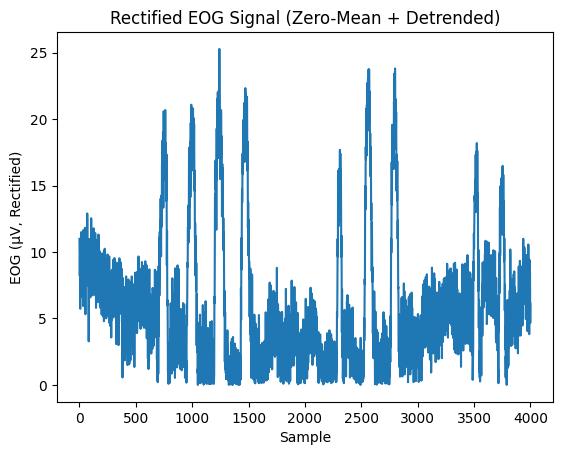

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import detrend


channel_data = channel_data - channel_data.mean()

# Remove slow drift (baseline wander)
channel_data = detrend(channel_data)

# --------------------------
# Rectification step (EOG)
# --------------------------
rectified_signal = abs(channel_data)   # full-wave rectification
# --------------------------

# Plot rectified EOG signal
plt.plot(rectified_signal)
plt.title("Rectified EOG Signal (Zero-Mean + Detrended)")
plt.ylabel("EOG (µV, Rectified)")
plt.xlabel("Sample")
plt.show()


The rectified EOG signal clearly highlights periods of muscle activation as increases in signal amplitude. High-amplitude, dense bursts appear at the beginning of the recording, corresponding to the highest level of muscle activity (4 repetitions). As the recording progresses, the amplitude and density of the rectified signal gradually decrease, reflecting reduced muscle activation levels during the 4, 3, 2, and 1 repetition phases. The unipolar nature of the rectified signal makes changes in muscle intensity easier to observe, while the remaining low-amplitude fluctuations represent baseline noise and minor involuntary muscle activity. Overall, the graph effectively demonstrates how rectification reveals the intensity pattern of muscle activation across decreasing effort levels.

**Rectified Filter**

To obtain a stable and physiologically meaningful representation of muscle activation, a moving average filter is applied as a smoothing technique. This filter acts as a low-pass operation on the rectified EOG, reducing short-term variability while preserving the overall activation pattern. By averaging the signal over a defined window, the moving average filter produces a smooth EOG envelope that reflects the intensity and timing of muscle contractions. This step is particularly useful for comparing different levels of muscle activity, such as the 4–3–2–1 activation sequence, and prepares the signal for quantitative analysis, including onset detection, amplitude measurement, and fatigue assessment.

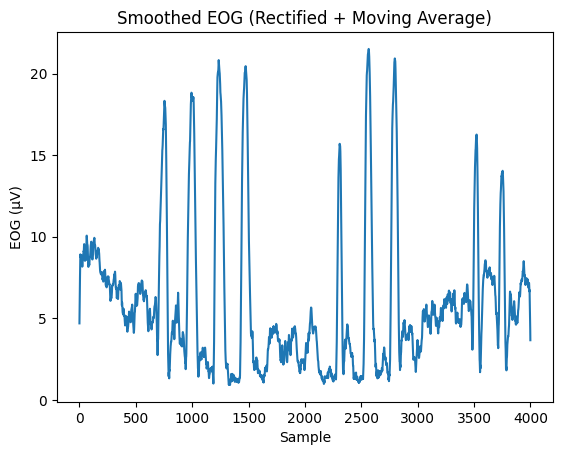

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import detrend
import numpy as np


# Subtract mean (zero-mean)
channel_data = channel_data - channel_data.mean()

# Remove slow drift (baseline wander)
channel_data = detrend(channel_data)

# Rectification
rectified_signal = np.abs(channel_data)

# --------------------------------------------------
# Moving Average Filter (window size adjustable)
# --------------------------------------------------
window_size = 15   # samples (adjust depending on your EOG sampling rate)
kernel = np.ones(window_size) / window_size
smoothed_signal = np.convolve(rectified_signal, kernel, mode='same')
# --------------------------------------------------

# Plot smoothed EOG
plt.plot(smoothed_signal)
plt.title("Smoothed EOG (Rectified + Moving Average)")
plt.ylabel("EOG (µV)")
plt.xlabel("Sample")
plt.show()


**Graph Analasy Do it later**

**What is better band pass filter is better or worse and sometimes**


**Conclusion**

To ensure accurate analysis, a sequential preprocessing pipeline is recommended. Band-pass filtering (typically 20–450 Hz) is applied first to isolate the physiological EOG frequency range while removing irrelevant low- and high-frequency components. Zero-meaning is then used to remove DC offsets and baseline drift. For amplitude-based analyses, the signal is rectified, converting all negative values to positive, and subsequently a low-pass filter is applied to the rectified signal to extract the EOG envelope, highlighting temporal patterns of muscle activation. This approach ensures a clean signal, preserves relevant physiological information, and enables robust quantification of muscle activity in both amplitude and temporal domains.

**Notch filter for EOG**

This script implements a digital filtering pipeline using Butterworth high-pass and low-pass filters, combined with a 50 Hz notch filter. The high-pass filter removes low-frequency baseline drift and movement artifacts, the notch filter eliminates mains power interference, and the low-pass filter attenuates high-frequency noise. Together, these filters preserve the physiological EOG signal within its characteristic frequency range, improving signal quality for subsequent analysis such as amplitude, frequency, and envelope detection. The script also provides a visualization of the filtered signal to facilitate verification of preprocessing effectiveness.

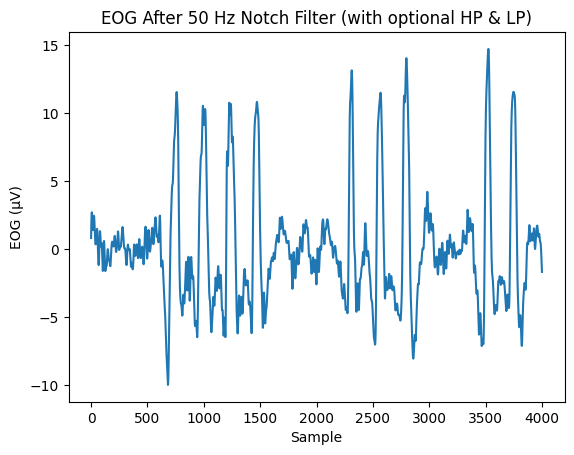

In [ ]:
from scipy import signal
import matplotlib.pyplot as plt

# ------------------------------------------------------
# High-pass filter
# ------------------------------------------------------
def butter_highpass_filter(data, cutoff, nyq, order=5):
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Low-pass filter
# ------------------------------------------------------
def butter_lowpass_filter(data, cutoff, nyq, order=5):
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# 50 Hz Notch Filter
# ------------------------------------------------------
def notch_filter(data, notch_freq, fs, Q=30):
    """
    notch_freq: frequency to remove (50 Hz)
    fs: sampling rate
    Q: quality factor (20-50 typical)
    """
    b, a = signal.iirnotch(w0=notch_freq, Q=Q, fs=fs)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Apply filters
# ------------------------------------------------------
channel_data_filtered = channel_data.copy()

fs = 250                # sampling frequency
nyq = fs * 0.5          # Nyquist
notch_freq = 50         # 50 Hz mains interference
Q = 30                  # notch filter sharpness

# Optional: high-pass + notch + low-pass
cutoff_high = 1         # example HP cutoff
cutoff_low = 15       # example LP cutoff

# 1. High-pass
channel_data_filtered = butter_highpass_filter(
    data=channel_data_filtered,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5
)

# 2. Notch (remove 50 Hz)
channel_data_filtered = notch_filter(
    data=channel_data_filtered,
    notch_freq=notch_freq,
    fs=fs,
    Q=Q
)

# 3. Low-pass
channel_data_filtered = butter_lowpass_filter(
    data=channel_data_filtered,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4
)

# ------------------------------------------------------
# Plot result
# ------------------------------------------------------
plt.plot(channel_data_filtered)
plt.title("EOG After 50 Hz Notch Filter (with optional HP & LP)")
plt.ylabel("EOG (µV)")
plt.xlabel("Sample")
plt.show()


**Validation Notch filter for EOG**

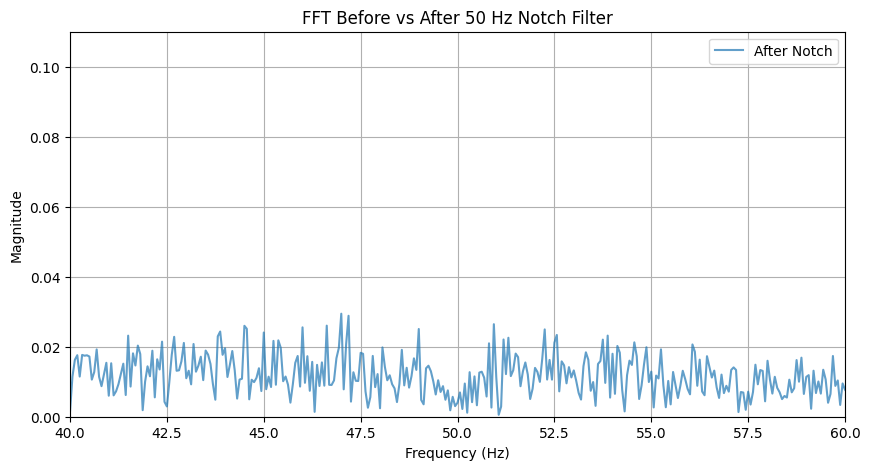

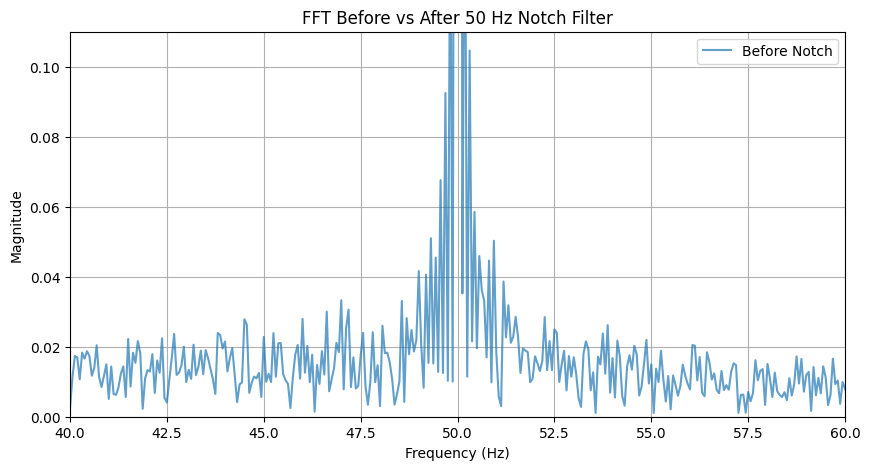

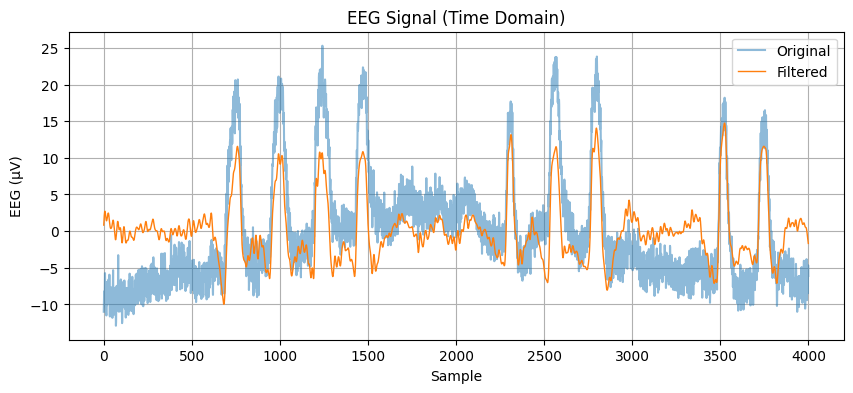

In [ ]:
import numpy as np

# ------------------------------------------------------
# FFT function
# ------------------------------------------------------
def compute_fft(data, fs):
    """
    Returns frequency axis and magnitude spectrum
    """
    n = len(data)
    fft_vals = np.fft.rfft(data)
    fft_mag = np.abs(fft_vals) / n
    freqs = np.fft.rfftfreq(n, d=1/fs)
    return freqs, fft_mag


def plot_fft_comparison(data_before, data_after, fs, title="FFT Comparison"):
    freqs_b, fft_b = compute_fft(data_before, fs)
    freqs_a, fft_a = compute_fft(data_after, fs)

    plt.figure(figsize=(10, 5))
    #plt.plot(freqs_b, fft_b, label="Before Notch", alpha=0.7)
    plt.plot(freqs_a, fft_a, label="After Notch", alpha=0.7)
    plt.xlim(0, 100)   # EOG relevant range
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xlim(40, 60)
    plt.ylim(0, 0.11)
    plt.show()



    plt.figure(figsize=(10, 5))
    plt.plot(freqs_b, fft_b, label="Before Notch", alpha=0.7)
    #plt.plot(freqs_a, fft_a, label="After Notch", alpha=0.7)
    plt.xlim(0, 100)   # EOG relevant range
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xlim(40, 60)
    plt.ylim(0, 0.11)
    plt.show()


channel_data_original = channel_data.copy()

# 1. High-pass
channel_data_hp = butter_highpass_filter(
    data=channel_data_original,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5
)

# 2. Notch (remove 50 Hz)
channel_data_notched = notch_filter(
    data=channel_data_hp,
    notch_freq=notch_freq,
    fs=fs,
    Q=Q
)

# 3. Low-pass
channel_data_filtered = butter_lowpass_filter(
    data=channel_data_notched,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4
)

plot_fft_comparison(
    data_before=channel_data_hp,
    data_after=channel_data_notched,
    fs=fs,
    title="FFT Before vs After 50 Hz Notch Filter"
)

plt.figure(figsize=(10, 4))
plt.plot(channel_data_original, label="Original", alpha=0.5)
plt.plot(channel_data_filtered, label="Filtered", linewidth=1)
plt.title("EOG Signal (Time Domain)")
plt.xlabel("Sample")
plt.ylabel("EOG (µV)")
plt.legend()
plt.grid(True)
plt.show()




**Band-Pass Filters**

**Graph Analasy Do it later**

Text 48-52 Hz

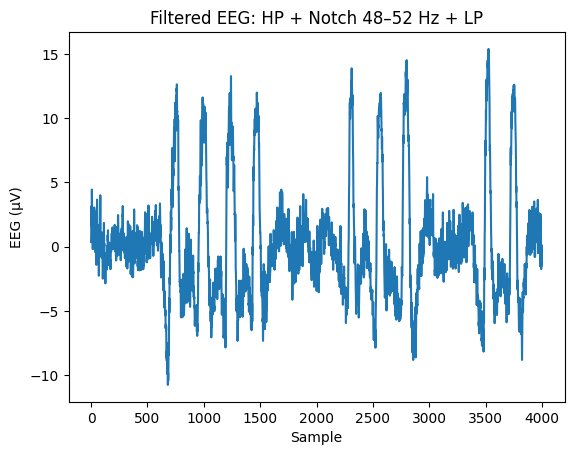

In [ ]:
from scipy import signal
import matplotlib.pyplot as plt

# ------------------------------------------------------
# High-pass filter
# ------------------------------------------------------
def butter_highpass_filter(data, cutoff, nyq, order=5):
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Low-pass filter
# ------------------------------------------------------
def butter_lowpass_filter(data, cutoff, nyq, order=5):
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Band-stop (NOTCH) filter for 48–52 Hz
# ------------------------------------------------------
def butter_bandstop_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='bandstop')
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Apply all filters
# ------------------------------------------------------
channel_data_filtered = channel_data.copy()

fs = 250                      # sampling rate
nyq = fs * 0.5                # Nyquist frequency

cutoff_high = 1               # high-pass cutoff
notch_low = 48                # notch start
notch_high = 52               # notch end
cutoff_low = 124              # low-pass cutoff

# 1. High-pass filter
channel_data_filtered = butter_highpass_filter(
    data=channel_data_filtered,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5
)

# 2. 48–52 Hz notch filter
channel_data_filtered = butter_bandstop_filter(
    data=channel_data_filtered,
    lowcut=notch_low,
    highcut=notch_high,
    fs=fs,
    order=4
)

# 3. Low-pass filter
channel_data_filtered = butter_lowpass_filter(
    data=channel_data_filtered,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4
)

# ------------------------------------------------------
# Plot final filtered signal
# ------------------------------------------------------
plt.plot(channel_data_filtered)
plt.title("Filtered EOG: HP + Notch 48–52 Hz + LP")
plt.ylabel("EOG (µV)")
plt.xlabel("Sample")
plt.show()


**graph analye later**

## Band Pass Filter

Band-pass filtering is a common signal processing technique used in EOG  data analysis to isolate specific frequency bands of interest while removing unwanted frequencies. Band-pass filtering allows researchers to focus on particular brainwave rhythms that are relevant to their study. For example, you might want to extract the alpha, beta, or gamma waves from the EOG data.  

You can read more about the band-pass filter in [Chapter 1](https://graceful-kelpie-579688.netlify.app/chapters/chapter_1-band_pass_filter).

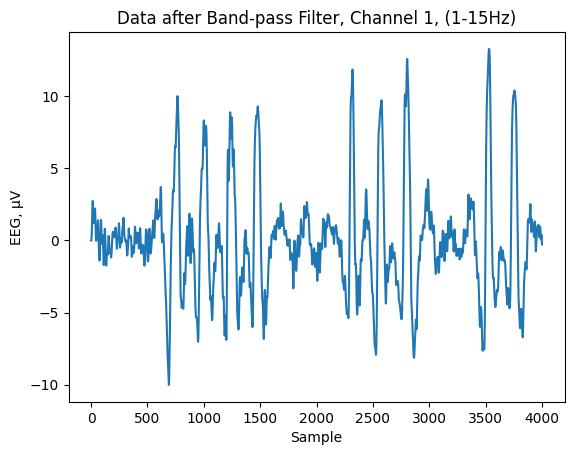

In [ ]:
def butter_highpass_filter(data, cutoff, nyq, order=5):
    """Butterworth high-pass filter.
    Args:
        data (array_like): data to be filtered.
        cutoff (float): cutoff frequency.
        order (int): order of the filter.
    Returns:
        array: filtered data."""
    normal_cutoff = cutoff / nyq  # normalized cutoff frequency
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

def butter_lowpass_filter(data, cutoff, nyq, order=5):
    """Butterworth low-pass filter.
    Args:
        data (array_like): data to be filtered.
        cutoff (float): cutoff frequency.
        order (int): order of the filter.
    Returns:
        array: filtered data."""
    normal_cutoff = cutoff / nyq  # normalized cutoff frequency
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = signal.lfilter(b, a, data)
    return filtered_data

channel_data_bp_filtered = channel_data_filtered #channel_data.copy()  # copy the data
fps = 250  # sampling frequency
cutoff_high = 1  # cutoff frequency of the high-pass filter
cutoff_low = 15  # cutoff frequency of the low-pass filter
nyq = 0.5 * fps  # Nyquist frequency (half of the sampling frequency)

# apply the band-pass filter
channel_data_bp_filtered = butter_highpass_filter(
    data=channel_data_bp_filtered,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5)
channel_data_bp_filtered = butter_lowpass_filter(
    data=channel_data_bp_filtered,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4)

plt.plot(channel_data_bp_filtered)
plt.title("Data after Band-pass Filter, Channel " +  str(channel+1) +", ("+str(cutoff_high)+"-"+str(cutoff_low) + "Hz)")
plt.ylabel('EOG, µV')
plt.xlabel('Sample')
plt.show()

**graph analye later**

**Smoothing filters**

Smoothing filters are essential tools in EOG signal processing, used to reduce noise and highlight underlying patterns. These filters work by averaging or weighting neighboring data points to create a smoother representation of the signal. The average filter computes the mean of nearby samples, reducing high-frequency noise.

##Average Filter

In EOG signal processing, calculating the average is a common technique used to improve the signal-to-noise ratio and highlight underlying muscle activity. EOG signals are often contaminated with high-frequency noise, motion artifacts, and baseline fluctuations. Averaging can reduce these unwanted components while preserving meaningful muscle activity patterns.



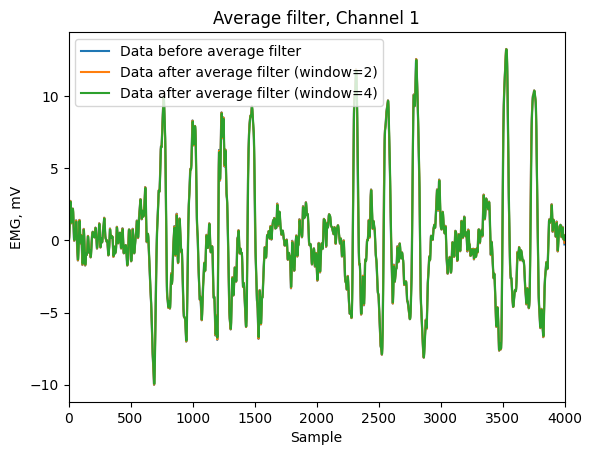

In [ ]:
def average_filter(data, average_length):
    """Average filter.
    Args:
        data (array_like): data to be filtered.
        average_length (int): length of the filter window.
    Returns:
        array: filtered data."""
    data = pd.DataFrame(data)
    avereged_data = data.rolling(window=average_length).mean()
    return avereged_data

# you can control the "smoothness" of the data by changing the window size
average_length_window_1 = 2
average_length_window_2 = 4

channel_data_avg_window_1 = average_filter(data=channel_data_bp_filtered, average_length=average_length_window_1)
channel_data_avg_window_2 = average_filter(data=channel_data_bp_filtered, average_length=average_length_window_2)

plt.title("Average filter, Channel " +  str(channel+1))
plt.plot(channel_data_bp_filtered, label='Data before average filter')
plt.plot(channel_data_avg_window_1, label='Data after average filter (window='+str(average_length_window_1)+")")
plt.plot(channel_data_avg_window_2, label='Data after average filter (window='+str(average_length_window_2)+")")
plt.ylabel('EOG, mV')
plt.xlabel('Sample')
plt.legend(loc='upper left')
plt.xlim([0, 4000])  # zoom in the data
plt.show()

**Gaussian Filter**

Applying a Gaussian filter to EOG data is a common signal processing technique used for smoothing and noise reduction. A Gaussian filter is a linear smoothing filter that convolves the EOG signal with a Gaussian kernel, reducing high-frequency noise while preserving underlying muscle activity patterns.


A Gaussian filter for EOG works by convolving the signal with a Gaussian-shaped curve. Points near the center of the window are weighted more heavily, while points further away have lower weight. The standard deviation of the Gaussian determines the amount of smoothing: smaller values maintain fast muscle activity changes, while larger values provide stronger noise reduction. This makes Gaussian filters suitable for visualizing temporal patterns of EOG activation and reducing noise without losing critical physiological information.

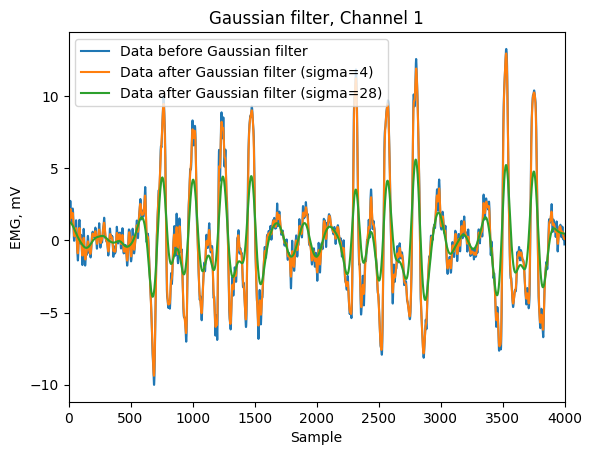

In [ ]:
from scipy.ndimage import gaussian_filter1d

# you can control the "smoothness" of the data by changing
# the kernel's standard deviation value
sigma_value_1 = 4 # standard deviation of the Gaussian kernel
sigma_value_2 = 28 # standard deviation of the Gaussian kernel

channel_data_gauss_window_1 = gaussian_filter1d(channel_data_bp_filtered, sigma=sigma_value_1)
channel_data_gauss_window_2 = gaussian_filter1d(channel_data_bp_filtered, sigma=sigma_value_2)

# plot the data
plt.title("Gaussian filter, Channel " +  str(channel+1))
plt.xlabel("Sample")
plt.ylabel("EOG, mV")
plt.plot(channel_data_bp_filtered, label='Data before Gaussian filter')
plt.plot(channel_data_gauss_window_1, label='Data after Gaussian filter (sigma='+str(sigma_value_1)+")")
plt.plot(channel_data_gauss_window_2, label='Data after Gaussian filter (sigma='+str(sigma_value_2)+")")
plt.legend(loc='upper left')
plt.xlim([0, 4000])  # zoom in the data
plt.show()

## Median Filter

The median filter is a widely used signal processing technique for EOG data, effective for denoising and removing outliers. Each EOG data point is replaced with the median value of its neighboring points within a defined window, reducing transient noise while preserving sharp bursts and rapid muscle activity changes.



**How it works**

A median filter for EOG replaces each data point with the median value of neighboring points within a specified window. This method effectively suppresses isolated spikes and impulsive noise while preserving important features of muscle activity such as rapid contractions and transient bursts.

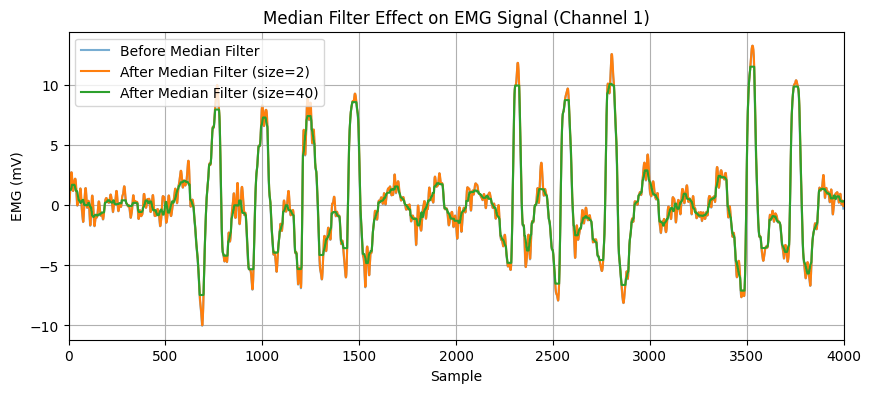

In [ ]:
from scipy import ndimage
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Median filter window sizes
# ------------------------------------------------------
size_window_1 = 2
size_window_2 = 40

# Apply median filters
channel_data_median_window_1 = ndimage.median_filter(
    channel_data_bp_filtered, size=size_window_1
)

channel_data_median_window_2 = ndimage.median_filter(
    channel_data_bp_filtered, size=size_window_2
)

# ------------------------------------------------------
# Plot BEFORE and AFTER median filtering
# ------------------------------------------------------
plt.figure(figsize=(10, 4))

# Before
plt.plot(
    channel_data_bp_filtered,
    label='Before Median Filter',
    alpha=0.6
)

# After (choose one or show both)
plt.plot(
    channel_data_median_window_1,
    label=f'After Median Filter (size={size_window_1})'
)

plt.plot(
    channel_data_median_window_2,
    label=f'After Median Filter (size={size_window_2})'
)

plt.title(f"Median Filter Effect on EOG Signal (Channel {channel + 1})")
plt.xlabel("Sample")
plt.ylabel("EOG (mkV)")
plt.legend(loc='upper left')
plt.xlim(0, 4000)   # zoom
plt.grid(True)

plt.show()


**Detect EOG data**

This script demonstrates a simple algorithm for processing surface EOG signals to detect muscle activation periods.

Binary activation detection: The smoothed EOG amplitude is converted into a binary signal (0/1) representing muscle inactivity or activity. This is achieved using a threshold value, which can be manually defined or adaptively calculated based on the mean and standard deviation of the signal.

Visualization: The script displays both the smoothed EOG signal and the corresponding binary activation signal, allowing for visual assessment of muscle activation patterns.

This approach provides a simple method for preprocessing EOG signals and extracting activation events, which can be used for further analysis, such as timing, activation onset, or studying muscle coordination.

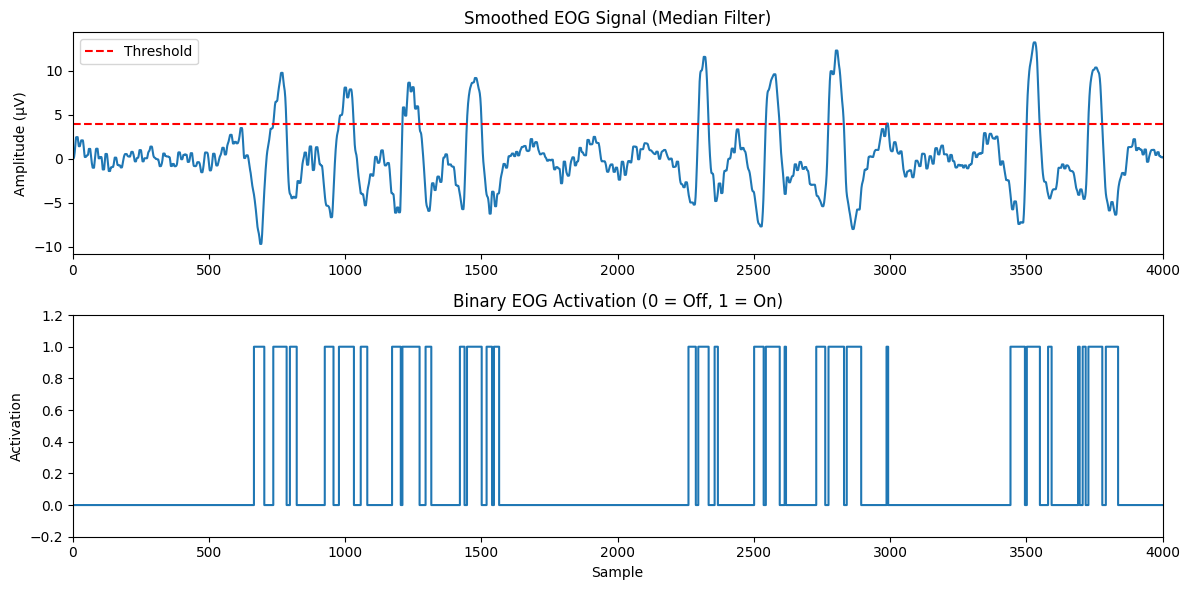

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# ------------------------------------------------------
# 1. Smooth EOG using your median filters
# ------------------------------------------------------
size_window_1 = 5
size_window_2 = 10

smoothed_eog = ndimage.median_filter(channel_data_bp_filtered, size=size_window_2)

# ------------------------------------------------------
# 2. Convert EOG amplitude into binary activation (0/1)
# ------------------------------------------------------
# Option A: Manual threshold
threshold = np.mean(smoothed_eog) +  np.std(smoothed_eog)   # adaptive threshold

eog_binary = (np.abs(smoothed_eog) > threshold).astype(int)

# ------------------------------------------------------
# 3. Plot original EOG and binary EOG
# ------------------------------------------------------
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(smoothed_eog)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.title("Smoothed EOG Signal (Median Filter)")
plt.ylabel("Amplitude (µV)")
plt.xlim([0, 4000])

plt.legend()

plt.subplot(2,1,2)
plt.plot(eog_binary, drawstyle='steps-post')
plt.title("Binary EOG Activation (0 = Off, 1 = On)")
plt.xlabel("Sample")
plt.ylabel("Activation")
plt.ylim([-0.2, 1.2])

plt.xlim([0, 4000])

plt.tight_layout()
plt.show()




This script implements an automated method for detecting muscle activation periods from processed EOG signals. The goal is to identify time segments where the EOG amplitude exceeds a defined threshold, representing active muscle contractions, while filtering out short, spurious fluctuations.


**Threshold-based activation detection**  
The EOG signal amplitude is compared to a threshold, which can be defined manually or adaptively (mean + factor × standard deviation). Periods above the threshold are considered candidate activations.

**Merging nearby activations**  
Short gaps between activations that fall within a defined merge window are combined to account for brief signal interruptions, ensuring continuous bursts of activity are correctly identified.

**Minimum duration filtering**  
Candidate activations shorter than a specified minimum duration are discarded, preventing transient noise from being misclassified as muscle activation.

Binary activation vector and segment extraction: The script outputs both a binary vector (0 = inactive, 1 = active) and a list of start-end indices for each detected activation segment.

**Visualization**  
 The filtered EOG signal is plotted alongside the detected activation periods, providing an intuitive representation of muscle activity patterns.


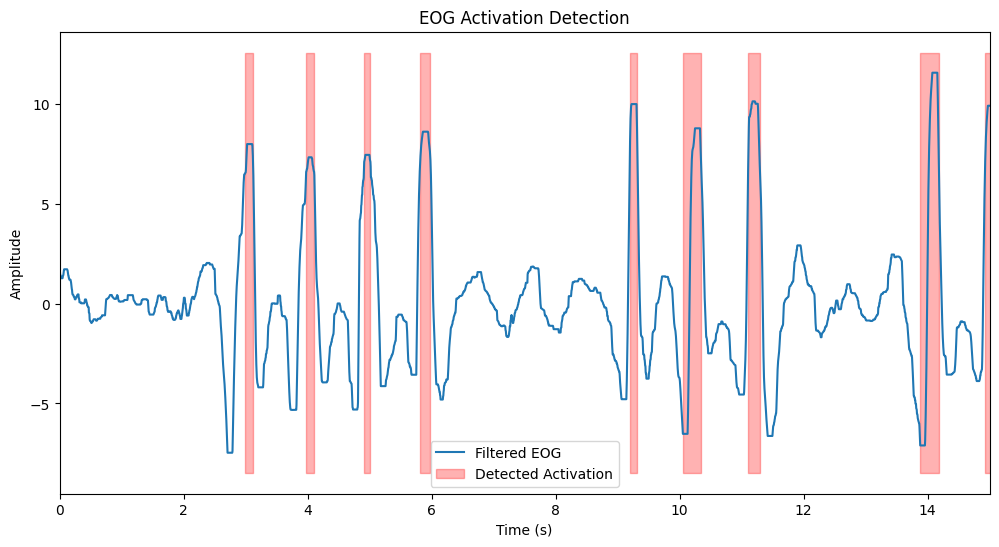

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# PARAMETERS
# ------------------------------
fs = 250  # Sampling rate in Hz
merge_window_ms = 100       # Time window to merge nearby activations
threshold_factor = 1.8        # Threshold = mean + factor*std
min_duration_sec = 0.1     # Minimum duration of an activation to keep it

# ------------------------------
# EOG ACTIVATION DETECTOR FUNCTION
# ------------------------------
def detect_eog_activation(x, fs, threshold=None, merge_window_ms=100, min_duration_sec=0.5):
    """
    Detect EOG activation segments from a 1D signal.

    Parameters:
        x : array-like, EOG signal
        fs : sampling rate (Hz)
        threshold : activation threshold (if None, set to mean + 2*std)
        merge_window_ms : merge peaks within this time window (ms)
        min_duration_sec : minimum duration of activation to keep it (seconds)

    Returns:
        segments : list of tuples (start_idx, end_idx)
        act_vec : binary vector of activations (0=off, 1=on)
    """
    if threshold is None:
        threshold = np.mean(x) + threshold_factor * np.std(x)

    amp = np.abs(x)
    act = amp > threshold
    merge_samples = int((merge_window_ms / 1000) * fs)
    min_samples = int(min_duration_sec * fs)
    idx = np.where(act)[0]

    if len(idx) == 0:
        return [], np.zeros(len(x))

    segments = []
    start = idx[0]

    for i in range(1, len(idx)):
        if idx[i] - idx[i - 1] > merge_samples:
            end = idx[i - 1]
            if end - start + 1 >= min_samples:  # keep only if long enough
                segments.append((start, end))
            start = idx[i]

    # last segment
    end = idx[-1]
    if end - start + 1 >= min_samples:
        segments.append((start, end))

    act_vec = np.zeros(len(x))
    for s, e in segments:
        act_vec[s:e] = 1

    return segments, act_vec

# ------------------------------
# LOAD / USE FILTERED EOG
# ------------------------------
#x = channel_data_bp_filtered  #  channel_data_avg_window_2 #

x = channel_data_avg_window_2[0].dropna().to_numpy()
x = channel_data_median_window_2
#x = np.array(channel_data_avg_window_2)  #  channel_data_avg_window_2 #

#print (channel_data_bp_filtered)
#print ("after")
#print (channel_data_avg_window_2)

t = np.arange(len(x)) / fs    # create time vector in seconds

# ------------------------------
# DETECT ACTIVATIONS
# ------------------------------
segments, act_vec = detect_eog_activation(
    x, fs, threshold=None, merge_window_ms=merge_window_ms, min_duration_sec=min_duration_sec
)

# ------------------------------
# PLOTTING
# ------------------------------
plt.figure(figsize=(12, 6))

# EOG signal
plt.plot(t, x, label='Filtered EOG', linewidth=1.5)

# Highlight detected activations
plt.fill_between(t, min(x)-1, max(x)+1, where=act_vec>0, color='red', alpha=0.3, label='Detected Activation')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('EOG Activation Detection')
plt.legend()
plt.xlim([0, 15])

plt.show()


This script provides a method for detecting active muscle periods in EOG signals using a zero‑activity detection approach. Instead of directly thresholding the EOG amplitude, this method identifies periods where the signal is effectively “inactive”—i.e., below a defined threshold for a minimum duration—and defines the remaining segments as active muscle contractions.

The workflow consists of the following steps:
  
**Zero-period detection**  
The EOG signal is converted into a binary representation where points below the threshold are marked as inactive (0). Continuous zero periods are labeled and filtered based on a minimum duration, ensuring that only sustained inactivity is considered.

**Active period extraction**  
The active periods are identified as the complement of zero periods. This ensures that muscle activations are separated from sustained inactivity, even in signals with variable amplitude.

**Binary activation vector**  
The script outputs both a binary vector (1 = active, 0 = inactive) and a list of start-end indices for each active segment, facilitating quantitative analysis.

**Visualization**  
The EOG signal is plotted with detected active periods highlighted, allowing intuitive assessment of muscle activity timing and duration.

This zero‑period approach is particularly useful in situations where EOG signals have baseline fluctuations or variable amplitudes, and it provides a robust framework for analyzing muscle activation patterns in studies of motor control, neuromuscular coordination, or rehabilitation monitoring.

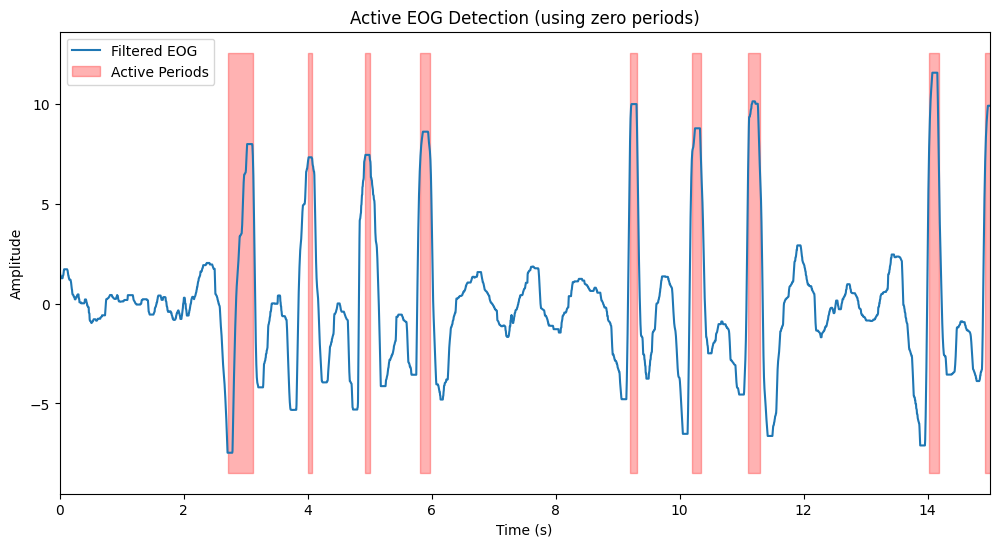

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# ------------------------------
# PARAMETERS
# ------------------------------
fs = 250                 # Sampling rate in Hz
threshold_factor = 2     # Threshold = mean + factor*std
min_zero_duration_sec = 0.7  # Minimum duration to mark as inactive

# ------------------------------
# ACTIVE DETECTION BASED ON ZERO PERIODS
# ------------------------------
def detect_active_from_zero(x, fs, threshold=None, min_zero_duration_sec=0.5):
    """
    Detect active EOG periods using zero activity detection.

    Active periods = 1, inactive (zero) periods = 0

    Parameters:
        x : array-like, EOG signal
        fs : sampling rate
        threshold : any signal below this is considered zero (if None, mean + 2*std is used)
        min_zero_duration_sec : minimum duration to mark as zero (seconds)

    Returns:
        segments : list of tuples (start_idx, end_idx) of active periods
        act_vec : binary vector (1 = active, 0 = inactive)
    """
    if threshold is None:
        threshold = np.mean(x) + threshold_factor * np.std(x)

    # Binary vector where signal is below threshold (zero periods)
    zero = np.abs(x) < threshold

    # Label continuous zero regions
    labeled, n_labels = label(zero)

    act_vec = np.ones(len(x))  # initialize all as active
    min_samples = int(min_zero_duration_sec * fs)
    segments_zero = []

    for i in range(1, n_labels+1):
        idx = np.where(labeled == i)[0]
        if len(idx) >= min_samples:
            start, end = idx[0], idx[-1]
            act_vec[start:end+1] = 0  # mark inactive
            segments_zero.append((start, end))

    # Active segments are complementary to zero segments
    segments_active = []
    current_start = None
    for i, val in enumerate(act_vec):
        if val == 1 and current_start is None:
            current_start = i
        elif val == 0 and current_start is not None:
            segments_active.append((current_start, i-1))
            current_start = None
    if current_start is not None:
        segments_active.append((current_start, len(act_vec)-1))

    return segments_active, act_vec

# ------------------------------
# LOAD / USE FILTERED EOG
# ------------------------------
x = channel_data_median_window_2 #[0].dropna().to_numpy()
t = np.arange(len(x)) / fs

# ------------------------------
# DETECT ACTIVE PERIODS
# ------------------------------
segments_active, act_vec = detect_active_from_zero(
    x, fs, threshold=None, min_zero_duration_sec=min_zero_duration_sec
)

# ------------------------------
# PLOTTING
# ------------------------------
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Filtered EOG', linewidth=1.5)
plt.fill_between(t, min(x)-1, max(x)+1, where=act_vec>0, color='red', alpha=0.3, label='Active Periods')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim([0, 15])
plt.title('Active EOG Detection (using zero periods)')
plt.legend()
plt.show()


This script implements an unsupervised machine learning approach for detecting active muscle periods in EOG signals using K-Nearest Neighbors (KNN). Instead of relying on a fixed threshold, the method identifies segments where EOG activity deviates significantly from the local signal patterns, making it robust to amplitude variability and baseline fluctuations.

The workflow consists of the following steps:

**Feature creation using sliding windows**  
The EOG signal is segmented into overlapping windows, and each window is treated as a multi-dimensional feature vector. This captures local temporal patterns in the signal, which are essential for detecting variations indicative of muscle activity.

**KNN distance computation**  
For each window, the mean distance to its nearest neighbors is calculated. Windows with distances significantly higher than the majority are considered to contain high EOG activity, as they differ from the local baseline.

**Activation detection**  
A threshold is set based on a chosen percentile of the distance distribution, classifying windows as either active (1) or inactive (0).

**Merging and gap filling**  
Short active periods below a minimum duration are removed, and brief dips within active periods that are shorter than a maximum allowable duration are merged, producing cleaner activation segments.

**Visualization **
The median-filtered EOG signal is plotted alongside the detected active periods, highlighting regions of significant muscle activation.

This unsupervised KNN-based approach provides a flexible and data-driven method for identifying EOG activations, particularly useful in signals with variable amplitude, complex patterns, or when adaptive thresholds are preferable over fixed ones. It is suitable for applications such as motor control studies, neuromuscular assessment, and rehabilitation monitoring.

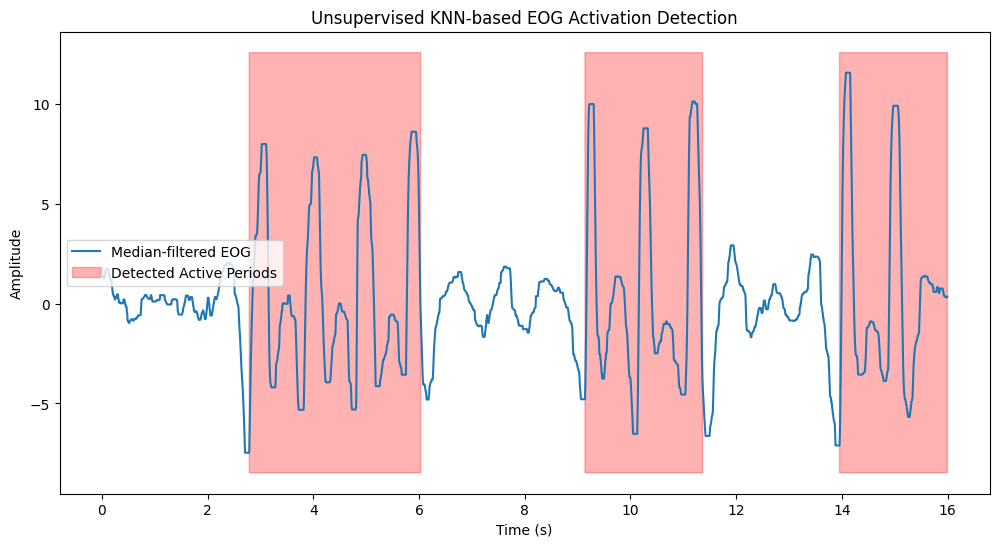

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ------------------------------
# PARAMETERS
# ------------------------------
fs = 250
window_size = 3           # Sliding window for KNN features
min_duration_sec = 0.05    # Minimum duration to keep activation
max_dip_duration_sec = 1.205 # Maximum short dip inside active periods to ignore

# ------------------------------
# LOAD DATA
# ------------------------------
try:
    x = channel_data_median_window_2 # channel_data_bp_filtered#channel_data_median_window_2.iloc[:,0].dropna().to_numpy()
except AttributeError:
    x = channel_data_median_window_2.flatten()
    x = x[~np.isnan(x)]

t = np.arange(len(x)) / fs

# ------------------------------
# CREATE FEATURES
# ------------------------------
half_win = window_size // 2
x_padded = np.pad(x, (half_win, half_win), mode='edge')
X = np.array([x_padded[i-half_win:i+half_win+1] for i in range(half_win, len(x_padded)-half_win)])

# ------------------------------
# KNN DISTANCE-BASED ACTIVATION
# ------------------------------
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X)
distances, _ = nbrs.kneighbors(X)
# Mean distance to neighbors
mean_dist = distances.mean(axis=1)

# High EOG activity → large distance from neighbors
# Set threshold as percentile (unsupervised)
threshold = np.percentile(mean_dist, 80)
act_vec = (mean_dist > threshold).astype(int)

# ------------------------------
# MERGE SHORT DIPS
# ------------------------------
min_samples = int(min_duration_sec * fs)
max_dip_samples = int(max_dip_duration_sec * fs)

# Merge short active bursts
merged_act = np.zeros_like(act_vec)
current_start = None
for i, val in enumerate(act_vec):
    if val == 1 and current_start is None:
        current_start = i
    elif val == 0 and current_start is not None:
        if i - current_start >= min_samples:
            merged_act[current_start:i] = 1
        current_start = None
if current_start is not None and len(act_vec) - current_start >= min_samples:
    merged_act[current_start:] = 1

# Fill short dips
zero_idx = np.where(merged_act==0)[0]
from scipy.ndimage import label as nd_label
labeled_segments, n_labels = nd_label(merged_act==0)
for i in range(1, n_labels+1):
    idx = np.where(labeled_segments==i)[0]
    if len(idx) <= max_dip_samples:
        merged_act[idx] = 1

# ------------------------------
# PLOTTING
# ------------------------------
plt.figure(figsize=(12,6))
plt.plot(t, x, label='Median-filtered EOG', linewidth=1.5)
plt.fill_between(t, min(x)-1, max(x)+1, where=merged_act>0, color='red', alpha=0.3, label='Detected Active Periods')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Unsupervised KNN-based EOG Activation Detection')
plt.legend()
plt.show()


What This Code Gives You


*   Computes iRMS using a sliding window
*   Produces a smooth power/amplitude envelope
*   Overlays it on your band-pass filtered signal
*   Fully compatible with your current pipeline
*   Window size adjustable in samples



**The instantaneous Root Mean Square (iRMS)**  
The instantaneous Root Mean Square (iRMS) is a widely used signal-processing technique for quantifying muscle activation in electromyography (EOG). By computing the square root of the mean of squared EOG amplitudes over a short, sliding window, iRMS provides a smoothed representation of the signal’s power while preserving rapid changes in muscle activity. This makes iRMS particularly effective for extracting the EOG envelope, enhancing signal-to-noise ratio, and reducing the influence of high-frequency artifacts that characterize raw EOG recordings. The resulting amplitude measure correlates strongly with motor unit firing intensity, enabling reliable assessment of muscle contraction level, fatigue, and activation timing. iRMS is therefore essential for transforming noisy EOG data into interpretable features for biomechanics research, human–machine interfaces, clinical diagnostics, and movement analysis.




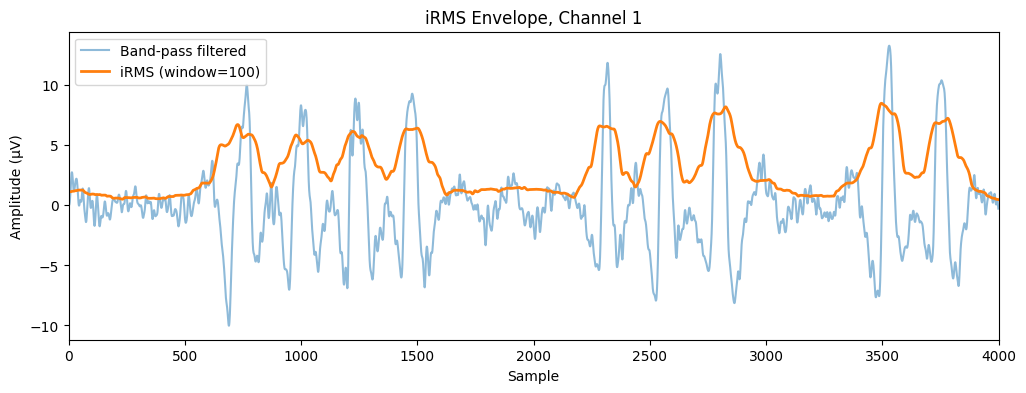

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Choose RMS window size (in samples) ----
# EOG typically uses 50–200 ms equivalent window depending on sampling rate
rms_window = 100    # change as needed

# ---- Compute iRMS ----
def compute_irms(signal, window_size):
    squared = signal ** 2
    window = np.ones(window_size) / window_size
    rms = np.sqrt(np.convolve(squared, window, mode='same'))
    return rms

channel_data_irms = compute_irms(channel_data_bp_filtered, rms_window)

# ---- Plot iRMS and raw band-pass data ----
plt.figure(figsize=(12,4))
plt.title("iRMS Envelope, Channel " + str(channel+1))
plt.xlabel("Sample")
plt.ylabel("Amplitude (µV)")

plt.plot(channel_data_bp_filtered, label="Band-pass filtered", alpha=0.5)
plt.plot(channel_data_irms, label="iRMS (window="+str(rms_window)+")", linewidth=2)

plt.legend(loc="upper left")
plt.xlim([0, 4000])
plt.show()


This script demonstrates the use of continuous wavelet transform (CWT) for analyzing EOG or EEG signals in the time–frequency domain. Unlike traditional amplitude-only or frequency-only analyses, wavelet analysis provides a simultaneous view of how signal power evolves over time and frequency, making it particularly useful for non-stationary signals such as EOG bursts or transient EOG events.

**The workflow includes the following steps:**

**Wavelet selection and scale definition**  
 A Morlet wavelet ('morl') is chosen for its good time–frequency localization. The wavelet is applied over a range of scales, which correspond to different frequencies, allowing the capture of both slow and fast components in the signal.

**Continuous wavelet transform computation**  
 The EOG signal is decomposed into wavelet coefficients, representing the magnitude of the signal at each scale (frequency) and time point.

**Normalization for visualization**
 The absolute values of the wavelet coefficients are normalized to enable consistent color mapping and to highlight regions of high relative power.

**Time–frequency visualization**
 A scalogram (heat map) is plotted, with time on the x-axis, frequency on the y-axis, and color representing normalized signal power. This allows the detection of transient activations, bursts, or rhythmic components in the EOG or EOG signal.

This approach provides a powerful tool for analyzing non-stationary electrophysiological signals, helping to identify temporal patterns in muscle activation, neural oscillations, or other physiological events that are difficult to capture with conventional Fourier-based methods.

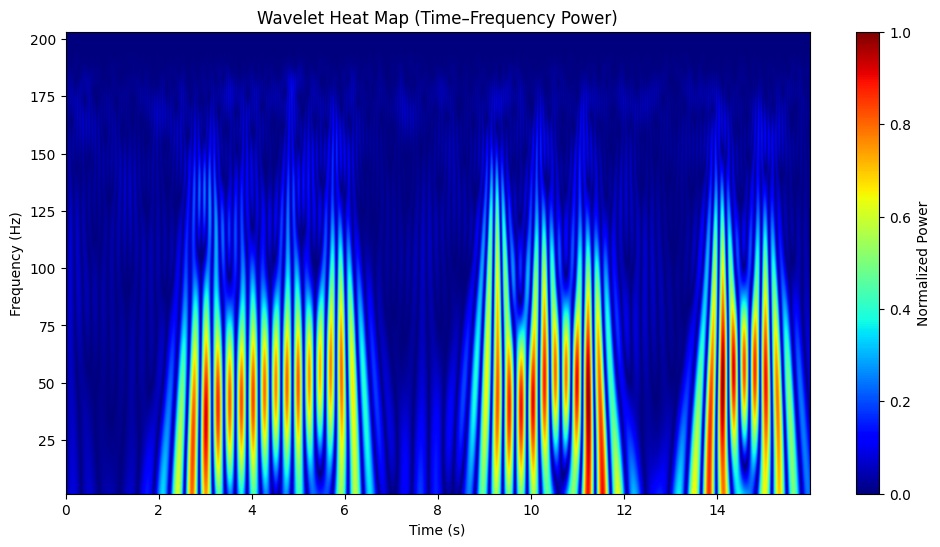

In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Load your signal
# ----------------------------------------------------
signal = channel_data_bp_filtered      # your filtered EEG/EOG channel
fs = 250                              # your sampling rate (Hz) — change if needed

# ----------------------------------------------------
# Define wavelet + scales
# ----------------------------------------------------
wavelet = 'morl'
scales = np.arange(1, 128)

# Compute scalogram
coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=1/fs)

# Normalize coefficients for visualization
abs_coeffs = np.abs(coeffs)
norm_coeffs = (abs_coeffs - abs_coeffs.min()) / (abs_coeffs.max() - abs_coeffs.min())

# Time axis (in seconds)
time = np.arange(len(signal)) / fs

# ----------------------------------------------------
# Plot wavelet heat map with frequency axis
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    norm_coeffs,
    extent=[time[0], time[-1], freqs[-1], freqs[0]],   # flip freq so low→high
    cmap='jet',
    aspect='auto',
    interpolation='bilinear'
)

ax.set_title('Wavelet Heat Map (Time–Frequency Power)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
#ax.set_xlim(0, 15)
#ax.set_ylim(195, 202)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Normalized Power')

plt.show()


This script provides methods for quantitative analysis of EOG signals using amplitude and power-based metrics. It computes the instantaneous root mean square (iRMS), total signal power, and integrated EOG (iEOG), which are commonly used to assess muscle activation intensity and overall neuromuscular activity.

The workflow consists of the following steps:

**Instantaneous RMS (iRMS) calculation**
The EOG signal is squared and convolved with a sliding window to compute the RMS over time. This produces a smoothed measure of muscle activation amplitude, highlighting transient bursts while reducing high-frequency noise.

**Total EOG power (20–450 Hz)**  
Using the Welch method, the power spectral density (PSD) of the EOG signal is calculated. The total power in the physiologically relevant EOG band (20–450 Hz) is integrated, providing a metric for the overall energy of the muscle activity.

**Integrated EOG (iEOG)**
The absolute values of the EOG signal are summed over time to obtain a single value representing cumulative muscle activity. This measure is useful for comparing total activation between conditions or muscles.

**Visualization**  
The script plots both the raw EOG signal and the iRMS trace, enabling visual assessment of activation patterns over time and the intensity of muscle contractions.

This approach provides a comprehensive framework for quantifying EOG amplitude and power, useful in neuromuscular studies, motor control analysis, fatigue assessment, and rehabilitation monitoring.

/tmp/ipython-input-296132064.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  eog_power = np.trapz(Pxx[band_mask], f[band_mask])  # area under PSD curve


Total EOG Power (20–450 Hz): 0.01
Integrated EOG (iEOG): 42.21


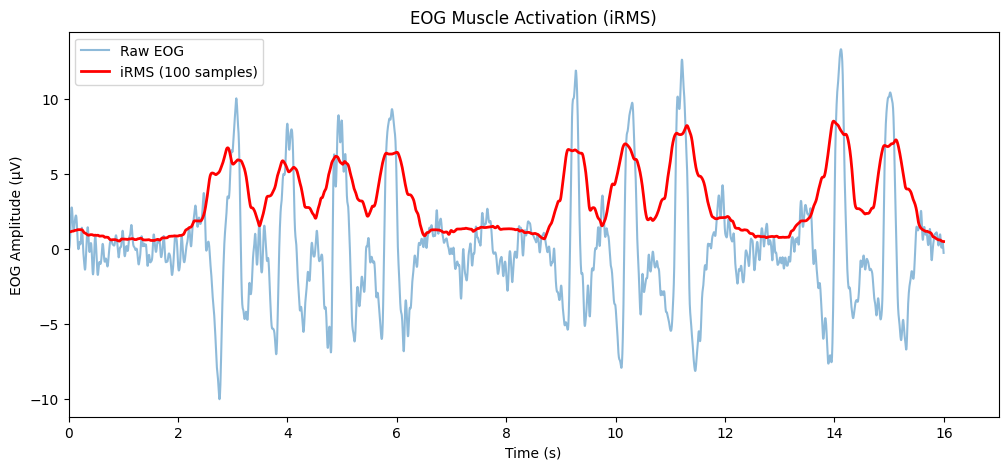

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------
# Input your data
# -------------------------
eog = channel_data_bp_filtered   # your EOG signal
fs = 250                        # sampling rate in Hz (change if needed)
rms_window = 100                 # RMS window size in samples (~100 ms)

# -------------------------
# 1) Instantaneous RMS (iRMS)
# -------------------------
def compute_irms(sig, window_size):
    squared = sig ** 2
    window = np.ones(window_size) / window_size
    rms = np.sqrt(np.convolve(squared, window, mode='same'))
    return rms

eog_irms = compute_irms(eog, rms_window)

# -------------------------
# 2) EOG Total Power (20–450 Hz)
# -------------------------
# Compute power spectral density using Welch method
f, Pxx = signal.welch(eog, fs=fs, nperseg=1024)
# Only keep EOG-relevant band
band_mask = (f >= 20) & (f <= 450)
eog_power = np.trapz(Pxx[band_mask], f[band_mask])  # area under PSD curve

print(f"Total EOG Power (20–450 Hz): {eog_power:.2f}")

# -------------------------
# 3) Integrated EOG (iEOG)
# -------------------------
ieog = np.sum(np.abs(eog)) / fs  # sum of absolute values over time
print(f"Integrated EOG (iEOG): {ieog:.2f}")

# -------------------------
# Plot RMS / iRMS
# -------------------------
time = np.arange(len(eog)) / fs

plt.figure(figsize=(12, 5))
plt.plot(time, eog, alpha=0.5, label="Raw EOG")
plt.plot(time, eog_irms, color='red', linewidth=2, label=f"iRMS ({rms_window} samples)")
plt.xlabel("Time (s)")
plt.ylabel("EOG Amplitude (µV)")
plt.title("EOG Muscle Activation (iRMS)")
plt.legend()
plt.xlim([0, 17])   # optional zoom-in
plt.show()


This script demonstrates a method for analyzing EOG signals by combining instantaneous RMS (iRMS) calculation with threshold-based binary activation detection. This approach allows for both quantitative assessment of muscle activity intensity and identification of active versus inactive periods.

The workflow includes the following steps:

**Instantaneous RMS (iRMS) calculation**  
The EOG signal is squared, averaged over a sliding window, and square-rooted to compute the RMS at each time point. This smooths the signal and highlights transient bursts of muscle activity while reducing high-frequency noise.

**Total EOG power (20–450 Hz)**  
Using the Welch method, the power spectral density is computed, and the total power in the physiologically relevant EOG band (20–450 Hz) is integrated. This provides a measure of overall muscle activation energy.

**Integrated EOG (iEOG)**  
The sum of the absolute EOG values over time is calculated, producing a metric representing cumulative muscle activation.

Threshold-based binary detection:
A threshold is applied to the iRMS signal to classify time points as either active (1) or inactive (0). The threshold can be set manually or adaptively (e.g., mean + 0.5 × standard deviation), allowing for robust detection of significant muscle contractions.

**Visualization:**  
The script provides two plots:

The raw EOG signal with iRMS and threshold for visualizing activation intensity.

The binary activation vector, indicating periods of high muscle activity.

This combined approach provides a comprehensive assessment of muscle activity, useful for neuromuscular research, fatigue analysis, motor control studies, and rehabilitation monitoring.

test

/tmp/ipython-input-3906106313.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  eog_power = np.trapz(Pxx[band_mask], f[band_mask])


Total EOG Power (20–450 Hz): 0.01
Integrated EOG (iEOG): 42.21
Detection Threshold = 4.1853


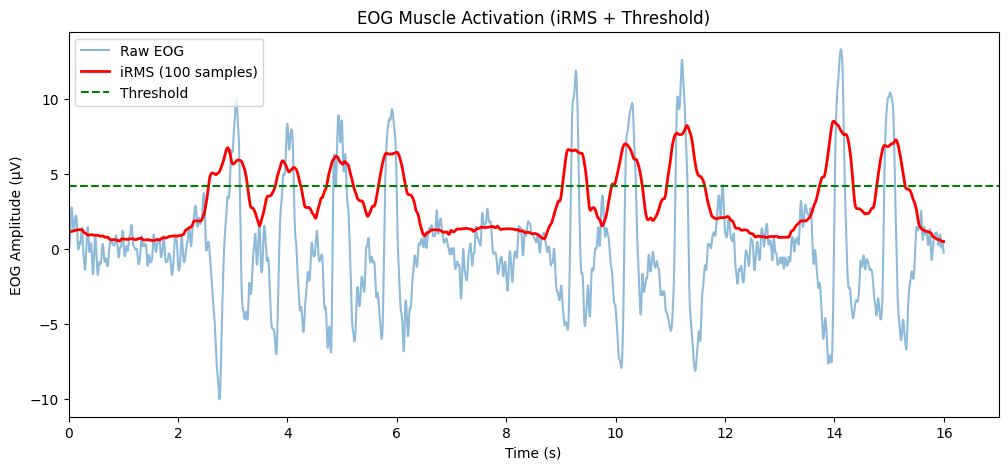

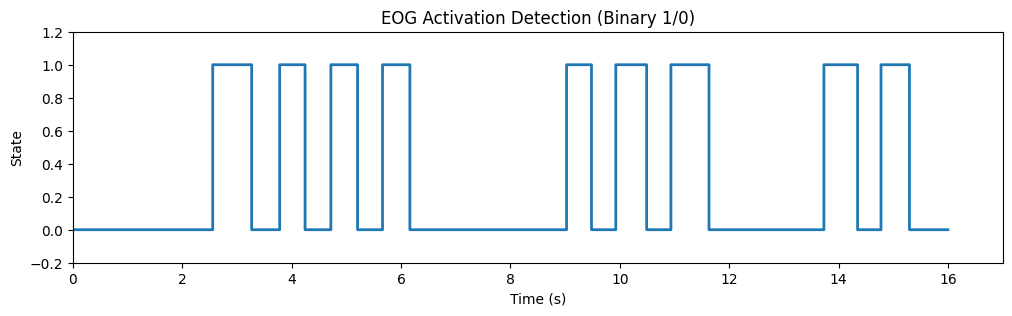

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------
# Input your data
# -------------------------
eog = channel_data_bp_filtered   # your EOG signal
fs = 250                       # sampling rate in Hz (change if needed)
rms_window = 100                 # RMS window size in samples (~100 ms)

# -------------------------
# 1) Instantaneous RMS (iRMS)
# -------------------------
def compute_irms(sig, window_size):
    squared = sig ** 2
    window = np.ones(window_size) / window_size
    rms = np.sqrt(np.convolve(squared, window, mode='same'))
    return rms

eog_irms = compute_irms(eog, rms_window)

# -------------------------
# 2) EOG Total Power (20–450 Hz)
# -------------------------
f, Pxx = signal.welch(eog, fs=fs, nperseg=1024)
band_mask = (f >= 20) & (f <= 450)
eog_power = np.trapz(Pxx[band_mask], f[band_mask])
print(f"Total EOG Power (20–450 Hz): {eog_power:.2f}")

# -------------------------
# 3) Integrated EOG (iEOG)
# -------------------------
ieog = np.sum(np.abs(eog)) / fs
print(f"Integrated EOG (iEOG): {ieog:.2f}")

# -------------------------
# 4) Binary EOG Detection (1 = high EOG)
# -------------------------

# AUTO THRESHOLD (you can change this)
threshold = np.mean(eog_irms) + 0.5 * np.std(eog_irms)

# detection vector (1 or 0)
eog_detect = (eog_irms > threshold).astype(int)

print(f"Detection Threshold = {threshold:.4f}")

# -------------------------
# Plots
# -------------------------

time = np.arange(len(eog)) / fs

# ---- Plot 1: Raw EOG + RMS ----
plt.figure(figsize=(12, 5))
plt.plot(time, eog, alpha=0.5, label="Raw EOG")
plt.plot(time, eog_irms, color='red', linewidth=2, label=f"iRMS ({rms_window} samples)")
plt.axhline(threshold, color='green', linestyle='--', label="Threshold")
plt.xlabel("Time (s)")
plt.ylabel("EOG Amplitude (µV)")
plt.title("EOG Muscle Activation (iRMS + Threshold)")
plt.legend()
plt.xlim([0, 17])  # optional
plt.show()

# ---- Plot 2: Binary Detection (1 = active, 0 = rest) ----
plt.figure(figsize=(12, 3))
plt.step(time, eog_detect, where='mid', linewidth=2)
plt.ylim([-0.2, 1.2])
plt.xlabel("Time (s)")
plt.ylabel("State")
plt.title("EOG Activation Detection (Binary 1/0)")
plt.xlim([0, 17])  # optional
plt.show()


This script provides a method for analyzing EOG signal power over time within a specific frequency band using a sliding-window FFT approach. The technique allows for quantifying the temporal evolution of muscle activity intensity in a physiologically relevant frequency range.

The workflow includes the following steps:

**Segmenting the EOG signal**  
The EOG signal is divided into consecutive windows of a specified duration (e.g., 1 second). Each window is treated as a separate segment for power analysis.

**Frequency-domain analysis using FFT**  
For each window, a Fast Fourier Transform (FFT) is computed to convert the EOG signal into the frequency domain. This enables assessment of the power spectral density of the signal.

**Band-specific power calculation**  
The signal power is integrated within a specified frequency band (e.g., 60–250 Hz), which corresponds to the primary physiological range of EOG activity. This provides a quantitative measure of muscle activation for each time window.

**Time-resolved visualization**  
The script plots EOG power versus time, allowing visualization of changes in muscle activation intensity over the recording period.

This sliding-window band power analysis is useful for tracking dynamic muscle activity, comparing conditions, detecting fatigue, and evaluating neuromuscular control in both research and clinical applications.

/tmp/ipython-input-1078932352.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.trapz(power_spectrum[band_mask], fft_freqs[band_mask])


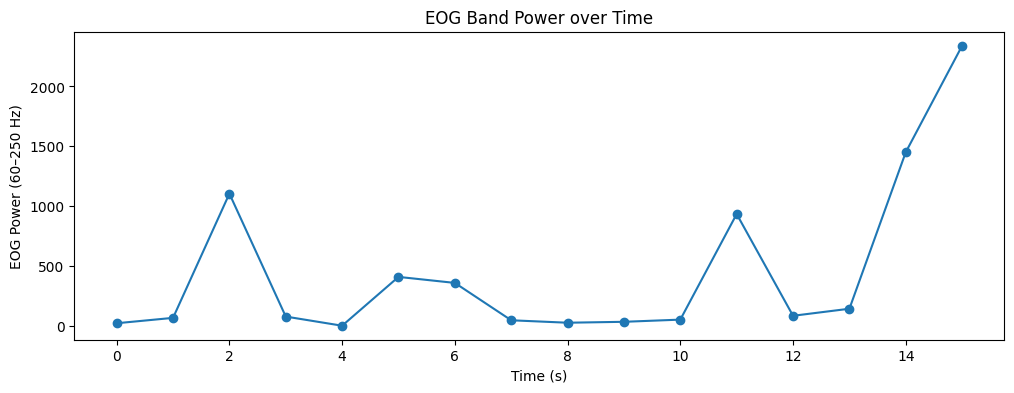

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Input EOG signal
# -----------------------
eog = channel_data_bp_filtered
fs = 250                # sampling rate in Hz
window_sec = 1           # window length in seconds
freq_band = (60, 250)    # frequency band for EOG power (Hz)

window_samples = int(window_sec * fs)
step_samples = window_samples  # non-overlapping, or use smaller for overlap

# -----------------------
# Sliding window power calculation
# -----------------------
n_windows = len(eog) // step_samples
power_time = []
time_axis = []

for i in range(n_windows):
    segment = eog[i*step_samples:(i+1)*step_samples]
    # FFT
    fft_vals = np.fft.rfft(segment)
    fft_freqs = np.fft.rfftfreq(len(segment), 1/fs)
    # Power spectrum
    power_spectrum = np.abs(fft_vals)**2
    # Integrate power in desired band
    band_mask = (fft_freqs >= freq_band[0]) & (fft_freqs <= freq_band[1])
    band_power = np.trapz(power_spectrum[band_mask], fft_freqs[band_mask])

    power_time.append(band_power)
    time_axis.append(i * window_sec)

# -----------------------
# Plot EOG power vs. time
# -----------------------
plt.figure(figsize=(12, 4))
plt.plot(time_axis, power_time, marker='o')
plt.xlabel("Time (s)")
plt.ylabel(f"EOG Power ({freq_band[0]}–{freq_band[1]} Hz)")
plt.title("EOG Band Power over Time")
plt.show()


**The end of the chapter 2**